In [1]:
!date

Fri Sep 18 22:33:57 PDT 2026


In [2]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr, mannwhitneyu
import matplotlib.pyplot as plt

projdir = '/u/project/cluo/terencew/claude/project_ideas/pool_design'

In [3]:
x = pd.read_csv(f'{projdir}/csv/ambisim/droplet_scores_cov.csv', sep='\t')
design = pd.read_csv(f'{projdir}/csv/designs/nominated_pools_n8.tsv', sep='\t')
design['pool'] = design['universe'] + '__' + design['strategy'] + '__rep' + design['rep'].astype(str)
design = design.drop_duplicates('pool')[['pool', 'min_dist', 'mean_dist', 'kl_min', 'kl_mean']]
x = x.merge(design, on='pool', how='left')

In [4]:
x.head()

,pool,universe,strategy,rep,modality,barcode,is_true_singlet,called_singlet,correct,donor_correct,...,n_snps,n_reads_demux,true_reads,called_donor,true_donor,heldout,min_dist,mean_dist,kl_min,kl_mean
0,AFR_only__greedy_maxmean__rep1,AFR_only,greedy_maxmean,1,gex,AAACAGCCAAACAACA,True,True,True,True,...,3232,3391,22915,HG02678,HG02678,False,104.52751,120.43151,1.886853,2.512456
1,AFR_only__greedy_maxmean__rep1,AFR_only,greedy_maxmean,1,gex,AAACAGCCAAACATAG,True,True,True,True,...,4130,4488,30010,HG02816,HG02816,False,104.52751,120.43151,1.886853,2.512456
2,AFR_only__greedy_maxmean__rep1,AFR_only,greedy_maxmean,1,gex,AAACAGCCAAACCCTA,True,True,True,True,...,2582,2843,19977,NA19922,NA19922,False,104.52751,120.43151,1.886853,2.512456
3,AFR_only__greedy_maxmean__rep1,AFR_only,greedy_maxmean,1,gex,AAACAGCCAAACCTAT,True,True,True,True,...,718,741,5237,NA20274,NA20274,False,104.52751,120.43151,1.886853,2.512456
4,AFR_only__greedy_maxmean__rep1,AFR_only,greedy_maxmean,1,gex,AAACAGCCAAACCTTG,True,True,True,True,...,6682,7458,51490,HG03136,HG03136,False,104.52751,120.43151,1.886853,2.512456


In [5]:
x.shape

(2303744, 25)

In [6]:
### WHY THIS NOTEBOOK EXISTS. everything before it called DIFF.LLK.BEST.NEXT "the LL-gap" and
### treated it as demuxlet's donor-discrimination margin. it is not. for a droplet called SNG,
### NEXT.GUESS is a doublet model (6705/6706 droplets in a spot-checked pool), so
### DIFF.LLK.BEST.NEXT == DIFF.LLK.SNG.DBL = the singlet-vs-doublet margin.
### the donor-vs-donor margin is SNG.BEST.LLK - SNG.NEXT.LLK, carried here as sng_gap.
### genetic distance between donors acts on sng_gap; ambient contamination acts on ll_gap.
called = x[x['is_true_singlet'] & x['called_singlet']]
for mod in ['gex', 'atac']:
    t = called[called['modality'] == mod]
    print(f'{mod}: ll_gap  (SNG vs DBL)        median={t["ll_gap"].median():8.2f}  p5={np.percentile(t["ll_gap"], 5):8.2f}')
    print(f'{mod}: sng_gap (best vs 2nd donor) median={t["sng_gap"].median():8.2f}  p5={np.percentile(t["sng_gap"], 5):8.2f}')
    print(f'      spearman(ll_gap, sng_gap) = {spearmanr(t["ll_gap"], t["sng_gap"])[0]:+.3f}')

gex: ll_gap  (SNG vs DBL)        median=    6.72  p5=   -0.80
gex: sng_gap (best vs 2nd donor) median=   53.90  p5=   12.64
      spearman(ll_gap, sng_gap) = +0.811
atac: ll_gap  (SNG vs DBL)        median=   19.43  p5=    1.22
atac: sng_gap (best vs 2nd donor) median=  135.58  p5=   35.79
      spearman(ll_gap, sng_gap) = +0.875


In [7]:
### the donor-discrimination threshold, on the margin that actually governs donor identity.
### this resolves far better than the ll_gap version in 01f because sng_gap spans the whole
### degradation range instead of bunching up near zero.
edges = [0, 1, 2, 3, 5, 7.5, 10, 15, 20, 30, 50, 75, 100, 150, 250, np.inf]
curve = []
for mod in ['gex', 'atac']:
    t = called[called['modality'] == mod].copy()
    t['bin'] = pd.cut(t['sng_gap'], edges, right=False)
    g = t.groupby('bin', observed=True).agg(n=('donor_correct', 'size'), acc=('donor_correct', 'mean'),
                                            med_snps=('n_snps', 'median'), med_reads=('true_reads', 'median'),
                                            med_llgap=('ll_gap', 'median')).reset_index()
    g['frac'] = g['n'] / g['n'].sum()
    g['modality'] = mod
    curve.append(g)
    print(f'--- {mod} ---')
    print(g.to_string(index=False, float_format=lambda v: f'{v:.5f}'))
curve = pd.concat(curve, ignore_index=True)

--- gex ---
           bin      n     acc    med_snps   med_reads  med_llgap    frac modality
    [2.0, 3.0)   1638 0.81746   696.00000  4938.00000   -0.74000 0.00188      gex
    [3.0, 5.0)   4670 0.92891   745.00000  5256.00000   -0.42000 0.00535      gex
    [5.0, 7.5)   8627 0.98041   833.00000  5870.00000   -0.10000 0.00988      gex
   [7.5, 10.0)  12046 0.99552   916.50000  6456.00000    0.30000 0.01380      gex
  [10.0, 15.0)  34411 0.99913  1085.00000  7684.00000    0.90000 0.03943      gex
  [15.0, 20.0)  44339 0.99991  1283.00000  9160.00000    1.66000 0.05080      gex
  [20.0, 30.0) 102815 1.00000  1586.00000 11370.00000    2.77000 0.11780      gex
  [30.0, 50.0) 194514 1.00000  2174.00000 15783.00000    5.02000 0.22287      gex
  [50.0, 75.0) 177284 1.00000  3030.00000 22222.00000    8.58000 0.20313      gex
 [75.0, 100.0) 108729 1.00000  3982.00000 29659.00000   12.83000 0.12458      gex
[100.0, 150.0) 107303 1.00000  5291.00000 40268.00000   18.58000 0.12295      gex
[150

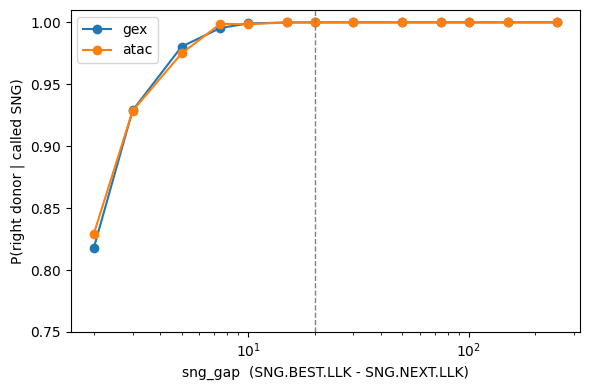

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
for mod, col in [('gex', 'C0'), ('atac', 'C1')]:
    g = curve[curve['modality'] == mod]
    ax.plot([iv.left for iv in g['bin']], g['acc'], 'o-', color=col, label=mod)
ax.axvline(20, ls='--', c='grey', lw=1)
ax.set_xscale('log'); ax.set_xlabel('sng_gap  (SNG.BEST.LLK - SNG.NEXT.LLK)')
ax.set_ylabel('P(right donor | called SNG)'); ax.set_ylim(0.75, 1.01); ax.legend()
plt.tight_layout()
plt.show()

In [9]:
### pool-level table carrying BOTH margins and ALL THREE design metrics
tab = []
for mod in ['gex', 'atac']:
    t = x[(x['modality'] == mod) & x['is_true_singlet']]
    g = t.groupby('pool').agg(acc=('correct', 'mean'), p_sng=('called_singlet', 'mean'),
                              universe=('universe', 'first'), strategy=('strategy', 'first'),
                              min_dist=('min_dist', 'first'), mean_dist=('mean_dist', 'first'),
                              kl_min=('kl_min', 'first'), heldout=('heldout', 'first'))
    cm = t[t['called_singlet']].groupby('pool')
    g['p_donor'] = cm['donor_correct'].mean()
    g['ll_gap'] = cm['ll_gap'].mean()
    g['sng_gap'] = cm['sng_gap'].mean()
    g['frac_below20'] = cm['sng_gap'].apply(lambda v: (v < 20).mean())
    g['modality'] = mod
    tab.append(g.reset_index())
tab = pd.concat(tab, ignore_index=True)

In [10]:
tab.head()

,pool,acc,p_sng,universe,strategy,min_dist,mean_dist,kl_min,heldout,p_donor,ll_gap,sng_gap,frac_below20,modality
0,AFR_only__adversarial_mindist__rep1,0.825904,0.826769,AFR_only,adversarial_mindist,100.000000,103.623207,1.406993,False,0.998955,10.133407,73.994243,0.103644,gex
1,AFR_only__adversarial_mindist__rep2,0.818373,0.818743,AFR_only,adversarial_mindist,99.779755,102.815285,1.382161,False,0.999548,9.803743,72.792698,0.105565,gex
2,AFR_only__adversarial_mindist__rep3,0.837881,0.838375,AFR_only,adversarial_mindist,102.235023,104.529594,1.422913,True,0.999411,9.936954,72.321356,0.112224,gex
3,AFR_only__greedy_maxkl__rep2,0.840598,0.841091,AFR_only,greedy_maxkl,112.565536,119.123520,1.678527,False,0.999413,10.150330,73.485273,0.103494,gex
4,AFR_only__greedy_maxkl__rep3,0.821212,0.822324,AFR_only,greedy_maxkl,113.229858,119.638237,1.685390,True,0.998649,9.885719,72.817904,0.108108,gex


In [11]:
tab.shape

(256, 14)

In [12]:
### min_dist vs mean_dist vs kl_min, against both margins and both halves of accuracy.
### CONVENTIONS rule 1: ordinary (adversarial-excluded) is the number that counts; the full
### sample is shown next to it because the adversarial pools are high-leverage by construction.
def block(metric):
    print(f'--- {metric} ---')
    for geo in ['min_dist', 'mean_dist', 'kl_min']:
        for lab, sub in [('ORDINARY', tab[~tab['strategy'].str.startswith('adversarial')]), ('ALL', tab)]:
            line = f'  {lab:9s} {geo:10s}'
            for mod in ['gex', 'atac']:
                s = sub[sub['modality'] == mod]
                r, pr = pearsonr(s[geo], s[metric])
                rho, ps = spearmanr(s[geo], s[metric])
                line += f' | {mod} r={r:+.3f}(p={pr:.4f}) rho={rho:+.3f}(p={ps:.4f})'
            print(line)

for m in ['sng_gap', 'll_gap', 'p_donor', 'p_sng', 'acc']:
    block(m)

--- sng_gap ---
  ORDINARY  min_dist   | gex r=+0.341(p=0.0004) rho=+0.349(p=0.0003) | atac r=+0.363(p=0.0001) rho=+0.352(p=0.0002)
  ALL       min_dist   | gex r=+0.653(p=0.0000) rho=+0.496(p=0.0000) | atac r=+0.726(p=0.0000) rho=+0.509(p=0.0000)
  ORDINARY  mean_dist  | gex r=+0.706(p=0.0000) rho=+0.717(p=0.0000) | atac r=+0.728(p=0.0000) rho=+0.731(p=0.0000)
  ALL       mean_dist  | gex r=+0.701(p=0.0000) rho=+0.720(p=0.0000) | atac r=+0.664(p=0.0000) rho=+0.745(p=0.0000)
  ORDINARY  kl_min     | gex r=+0.543(p=0.0000) rho=+0.528(p=0.0000) | atac r=+0.601(p=0.0000) rho=+0.572(p=0.0000)
  ALL       kl_min     | gex r=+0.711(p=0.0000) rho=+0.611(p=0.0000) | atac r=+0.770(p=0.0000) rho=+0.661(p=0.0000)
--- ll_gap ---
  ORDINARY  min_dist   | gex r=+0.320(p=0.0009) rho=+0.328(p=0.0006) | atac r=+0.319(p=0.0009) rho=+0.320(p=0.0009)
  ALL       min_dist   | gex r=+0.624(p=0.0000) rho=+0.492(p=0.0000) | atac r=+0.683(p=0.0000) rho=+0.488(p=0.0000)
  ORDINARY  mean_dist  | gex r=+0.714(p=0

In [13]:
### the adversarial pools, as their own comparison rather than something excluded.
### n=3 for each family arm -- CONVENTIONS rule 3, these are directionally clear but thin.
ordn = tab[~tab['strategy'].str.startswith('adversarial')]
for mod in ['gex', 'atac']:
    print(f'--- {mod} ---')
    o = ordn[ordn['modality'] == mod]
    for grp in ['adversarial_mindist', 'adversarial_family', 'adversarial_family_mixed']:
        a = tab[(tab['modality'] == mod) & (tab['strategy'] == grp)]
        line = f'  {grp:26s} n={len(a):2d}'
        for metric in ['sng_gap', 'll_gap', 'p_donor', 'acc']:
            u, pu = mannwhitneyu(a[metric], o[metric], alternative='less')
            line += f' | {metric}={a[metric].mean():.4f} vs {o[metric].mean():.4f} (p={pu:.4f})'
        print(line)

--- gex ---
  adversarial_mindist        n=17 | sng_gap=65.9194 vs 72.2575 (p=0.0017) | ll_gap=9.0020 vs 9.9988 (p=0.0006) | p_donor=0.9988 vs 0.9991 (p=0.0103) | acc=0.8357 vs 0.8429 (p=0.0095)
  adversarial_family         n= 3 | sng_gap=45.9100 vs 72.2575 (p=0.0000) | ll_gap=6.6394 vs 9.9988 (p=0.0000) | p_donor=0.9967 vs 0.9991 (p=0.0017) | acc=0.8262 vs 0.8429 (p=0.0130)
  adversarial_family_mixed   n= 3 | sng_gap=51.1692 vs 72.2575 (p=0.0000) | ll_gap=7.4183 vs 9.9988 (p=0.0000) | p_donor=0.9974 vs 0.9991 (p=0.0042) | acc=0.8199 vs 0.8429 (p=0.0047)
--- atac ---
  adversarial_mindist        n=17 | sng_gap=166.7698 vs 178.7475 (p=0.0004) | ll_gap=25.5200 vs 27.5837 (p=0.0005) | p_donor=0.9999 vs 1.0000 (p=0.0074) | acc=0.9145 vs 0.9179 (p=0.0002)
  adversarial_family         n= 3 | sng_gap=113.8199 vs 178.7475 (p=0.0000) | ll_gap=18.2094 vs 27.5837 (p=0.0000) | p_donor=0.9998 vs 1.0000 (p=0.0002) | acc=0.9074 vs 0.9179 (p=0.0020)
  adversarial_family_mixed   n= 3 | sng_gap=122.0977

In [14]:
### the bridge from margin to accuracy: pools differ in what FRACTION of their droplets sit
### below the threshold, and that fraction is what design moves.
for mod in ['gex', 'atac']:
    t = tab[tab['modality'] == mod]
    o = t[~t['strategy'].str.startswith('adversarial')]
    a = t[t['strategy'].str.startswith('adversarial')]
    print(f'{mod}: frac(sng_gap<20)  ordinary={o["frac_below20"].mean():.4f}  '
          f'adversarial={a["frac_below20"].mean():.4f}  overall range='
          f'{t["frac_below20"].min():.4f}-{t["frac_below20"].max():.4f}')
    for geo in ['min_dist', 'mean_dist', 'kl_min']:
        rho, p = spearmanr(o[geo], o['frac_below20'])
        print(f'    ordinary {geo:10s} ~ frac_below20: rho={rho:+.3f} p={p:.4f}')

gex: frac(sng_gap<20)  ordinary=0.1116  adversarial=0.1650  overall range=0.0712-0.2654
    ordinary min_dist   ~ frac_below20: rho=-0.304 p=0.0016
    ordinary mean_dist  ~ frac_below20: rho=-0.693 p=0.0000
    ordinary kl_min     ~ frac_below20: rho=-0.501 p=0.0000
atac: frac(sng_gap<20)  ordinary=0.0095  adversarial=0.0198  overall range=0.0053-0.0427
    ordinary min_dist   ~ frac_below20: rho=-0.302 p=0.0017
    ordinary mean_dist  ~ frac_below20: rho=-0.704 p=0.0000
    ordinary kl_min     ~ frac_below20: rho=-0.491 p=0.0000


In [15]:
### coverage-matched, now with all three metrics and the donor margin. the design effect on
### sng_gap is the same size in every coverage bin -- a uniform multiplicative scaling.
sedge = [0, 700, 1000, 1500, 2000, 3000, 5000, 8000, np.inf]
matched = []
for mod in ['gex', 'atac']:
    t = x[(x['modality'] == mod) & ~x['strategy'].str.startswith('adversarial')].copy()
    t['cov_bin'] = pd.cut(t['n_snps'], sedge, right=False)
    for cb, d in t.groupby('cov_bin', observed=True):
        pp = d.groupby('pool').agg(n=('correct', 'size'), p_sng=('called_singlet', 'mean'),
                                   min_dist=('min_dist', 'first'), mean_dist=('mean_dist', 'first'),
                                   kl_min=('kl_min', 'first'))
        cm = d[d['called_singlet']].groupby('pool')
        pp['sng_gap'] = cm['sng_gap'].mean()
        pp['p_donor'] = cm['donor_correct'].mean()
        pp = pp[pp['n'] >= 200]
        if len(pp) < 20:
            continue
        row = dict(modality=mod, cov_bin=str(cb), n_pools=len(pp), sng_gap=pp['sng_gap'].mean(),
                   p_sng=pp['p_sng'].mean(), p_donor=pp['p_donor'].mean())
        for geo in ['min_dist', 'mean_dist', 'kl_min']:
            row[f'rho_{geo}_sng_gap'], row[f'p_{geo}_sng_gap'] = spearmanr(pp[geo], pp['sng_gap'])
        row['rho_mean_dist_p_sng'], row['p_mean_dist_p_sng'] = spearmanr(pp['mean_dist'], pp['p_sng'])
        matched.append(row)
matched = pd.DataFrame(matched)
print(matched.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

modality          cov_bin  n_pools  sng_gap  p_sng  p_donor  rho_min_dist_sng_gap  p_min_dist_sng_gap  rho_mean_dist_sng_gap  p_mean_dist_sng_gap  rho_kl_min_sng_gap  p_kl_min_sng_gap  rho_mean_dist_p_sng  p_mean_dist_p_sng
     gex  [700.0, 1000.0)      105  14.4869 0.7315   0.9629                0.2500              0.0101                 0.6876               0.0000              0.4530            0.0000               0.0240             0.8081
     gex [1000.0, 1500.0)      105  22.9556 0.7454   0.9868                0.2975              0.0021                 0.7004               0.0000              0.4961            0.0000              -0.1121             0.2549
     gex [1500.0, 2000.0)      105  33.2364 0.7417   0.9936                0.3330              0.0005                 0.7264               0.0000              0.5246            0.0000              -0.1995             0.0414
     gex [2000.0, 3000.0)      105  49.4858 0.7520   0.9980                0.3372              0.0004   

In [16]:
### the GEX/ATAC split worth chasing (PROGRESS.md open question 7): mean_dist predicts the
### singlet/doublet call in ATAC but not in GEX, which is why pool "accuracy" tracks mean_dist
### in ATAC only.
for mod in ['gex', 'atac']:
    o = ordn[ordn['modality'] == mod]
    for geo in ['min_dist', 'mean_dist']:
        rho, p = spearmanr(o[geo], o['p_sng'])
        print(f'  {mod}: P(called SNG) ~ {geo:10s} rho={rho:+.3f} p={p:.4f}')

  gex: P(called SNG) ~ min_dist   rho=-0.152 p=0.1214
  gex: P(called SNG) ~ mean_dist  rho=-0.091 p=0.3557
  atac: P(called SNG) ~ min_dist   rho=+0.095 p=0.3376
  atac: P(called SNG) ~ mean_dist  rho=+0.460 p=0.0000


In [17]:
outdir = f'{projdir}/csv/ambisim'
tab.to_csv(f'{outdir}/pool_margins_n128.csv', sep='\t', index=False)
curve.to_csv(f'{outdir}/sng_gap_accuracy_curve.csv', sep='\t', index=False)
matched.to_csv(f'{outdir}/coverage_matched_design_allmetrics.csv', sep='\t', index=False)

In [18]:
!date

Fri Sep 18 22:34:18 PDT 2026
